# Оценка и тестирование RAG-систем

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 

* https://docs.ragas.io/en/stable/references/evaluate
* https://docs.ragas.io/en/stable/getstarted/rag_eval
* https://docs.ragas.io/en/stable/getstarted/rag_testset_generation
* https://docs.ragas.io/en/stable/references/generate/?h=generate_with_langchain_docs#ragas.testset.synthesizers.generate.TestsetGenerator.generate_with_chunks
* https://docs.ragas.io/en/stable/references/evaluation_schema/#ragas.testset.synthesizers.testset_schema.Testset.to_evaluation_dataset
* https://thedataguy.pro/blog/2025/04/generating-test-data-with-ragas/


## Задачи для самостоятельного решения

In [16]:
import os
import json
import pandas as pd
from typing import List, Literal, Dict

from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from openai import OpenAI

from datasets import Dataset
from ragas import evaluate
from ragas.metrics.collections import faithfulness, answer_relevancy
from ragas.testset import TestsetGenerator
from ragas.llms import llm_factory
from ragas.embeddings import HuggingFaceEmbeddings as RagasHuggingFaceEmbeddings
from ragas.embeddings import LangchainEmbeddingsWrapper

from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_BASE"] = os.environ["OPENAI_BASE_URL"] = "https://api.proxyapi.ru/openai/v1"


In [2]:
llm = ChatOpenAI(
    model="gpt-5.4-mini",
    temperature=0.0,
    api_key=os.environ.get("OPENAI_API_KEY"),
    base_url=os.environ.get("OPENAI_BASE_URL")
)

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    encode_kwargs={"normalize_embeddings": True}
)

doc_path = "data/prikaz-po-VKR-bak-i-mag_izmeneniya.txt"
loader = TextLoader(doc_path, encoding="utf-8")
chunks = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200).split_documents(loader.load())

vectorstore = Chroma.from_documents(chunks, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

openai_client = OpenAI(
    api_key=os.environ.get("OPENAI_API_KEY"),
    base_url=os.environ.get("OPENAI_BASE_URL")
)

ragas_llm = llm_factory(
    model="gpt-5.4-mini", 
    client=openai_client
)
ragas_embeddings = RagasHuggingFaceEmbeddings(
    model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
del ragas_llm.model_args['max_tokens'] # иначе будет много ошибок в номере 3

<p class="task" id="1"></p>
1. Реализуйте собственного агента для проверки ответов на наличие галлюцинаций. 

Для этого опишите структуру оценки в виде класса `Pydantic` с двумя полями: бинарная оценка (1 — факт подтвержден, 0 — галлюцинация) и текстовое обоснование решения. Создайте объект модели с поддержкой структурированного вывода на основе этого класса.

Составьте системный промпт, который заставляет модель действовать следующим образом: разбивать проверяемый ответ на утверждения и сверять каждое с предоставленным контекстом. Протестируйте судью на искусственном примере, где ответ модели явно противоречит контексту (например, путает даты или события). Выведите на экран полученный объект оценки с аргументацией.

- [ ] Проверено на семинаре


In [4]:
class FucktCheck(BaseModel):
    """Схема для оценки ответа на предмет галлюцинаций относительно предоставленного контекста."""
    
    is_supported: Literal[0, 1] = Field(
        description="Бинарная оценка. 1 — если ВСЕ факты из ответа подтверждаются контекстом. 0 — если присутствует хотя бы одна галлюцинация или противоречие."
    )
    reasoning: str = Field(
        description="Пошаговое логическое обоснование оценки. Необходимо разбить ответ на утверждения и сверить каждое с контекстом."
    )

In [5]:
evaluator_llm = llm.with_structured_output(FucktCheck)

judge_prompt = ChatPromptTemplate.from_messages([
    ("system", """Ты — строгий и беспристрастный судья (LLM-as-a-Judge). 
Твоя единственная цель — проверить, основан ли предоставленный 'Ответ' ИСКЛЮЧИТЕЛЬНО на 'Контексте'.

Алгоритм действий:
1. Выдели все утверждения из 'Ответа'.
2. Найди подтверждение каждому утверждению в 'Контексте'.
3. Если хотя бы одно утверждение из 'Ответа' противоречит контексту или вообще в нем не упоминается — это галлюцинация, ставь 0.
4. Если все утверждения четко следуют из контекста — факт подтвержден, ставь 1.
5. Напиши детальное обоснование."""),
    ("human", "Контекст:\n{context}\n\nОтвет модели:\n{answer}")
])

Мне кажется, что стоит подсмотреть крутой промпт в следующем задании. 

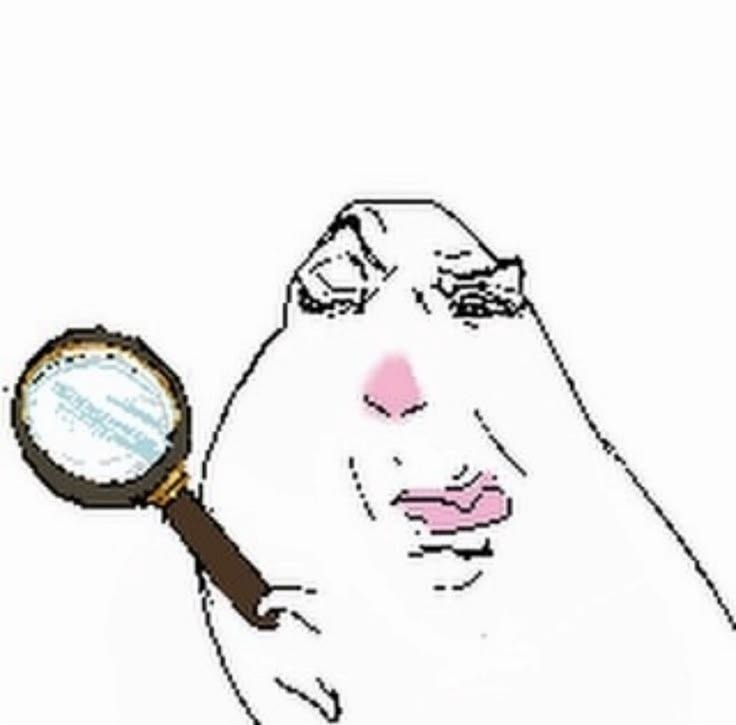

In [6]:
test_context = "В 2023 году компания выпустила продукт Alpha."
test_answer = "Продукт Alpha был выпущен в 2021 году."

In [7]:
judge_chain = judge_prompt | evaluator_llm  # Сокральный смысл этого выражения в том, что мы можем буквально передавать всё в большой объект последовательности, и он будет понимать, что сначала нужно отработать промпт, а потом результат передать в LLM для структурированного вывода, короче очень крутая штуковина
result = judge_chain.invoke({"context": test_context, "answer": test_answer})

print(result.is_supported)
print(result.reasoning)

0
В ответе содержится одно утверждение: «Продукт Alpha был выпущен в 2021 году». Контекст прямо говорит, что компания выпустила продукт Alpha в 2023 году. Следовательно, утверждение ответа противоречит контексту и не подтверждается им. По правилу оценки достаточно одной такой ошибки, чтобы поставить 0.


<p class="task" id="2"></p>

2\. В файле `rag_eval_data.json` предоставлены вопросы и эталонные ответы на вопросы по документу. Требуется подготовить датасет для оценки RAG системы. Он должен состоять из примеров, содержащий списки вопросов, ответов агента, найденных ретривером контекстов (обязательно в формате списка строк) и эталонных ответов. Ваша задача — создать простого агента с RAG на заданном документе, получить ответы модели и найденные контексты, оформить это в датасет нужного вида и сохранить результаты на диск.

Пример элемента датасета:

```
{
    "question": [
        "Когда компания выпустила продукт Alpha?"
    ],
    "answer": [
        "Компания выпустила продукт Alpha в 2023 году."
    ],
    "contexts": [
        ["В 2023 году компания выпустила продукт Alpha."]
    ],
    "ground_truth": [
        "Продукт Alpha был выпущен в 2023 году."
    ]
}

```


- [ ] Проверено на семинаре

In [8]:
eval_data_path = "data/rag_eval_data.json"

with open(eval_data_path, "r", encoding="utf-8") as f:
    eval_raw_data = json.load(f)

rag_prompt = ChatPromptTemplate.from_messages([
    ("system", "Ты полезный ИИ-ассистент. Отвечай на вопросы пользователя, опираясь строго на следующий контекст:\n\n{context}"),
    ("human", "{question}")
])

def ask_rag(question: str) -> dict:
    """Функция имитирует работу RAG-пайплайна: извлекает контекст и генерирует ответ."""
    retrieved_docs = retriever.invoke(question)
    contexts = [doc.page_content for doc in retrieved_docs]
    context_str = "\n---\n".join(contexts)
    
    response = llm.invoke(rag_prompt.format_messages(context=context_str, question=question))
    
    return {
        "answer": response.content,
        "contexts": contexts
    }
    

dataset_dict = {
    "user_input":[],          # Исходный вопрос пользователя
    "response": [],            # Ответ нашей RAG-системы
    "retrieved_contexts":[],  # Контексты, которые нашел retriever (List[str])
    "reference":[]            # Эталонный ответ (ground truth)
}

In [9]:

for item in eval_raw_data:
    q = item["question"]
    gt = item["ground_truth"]
    
    rag_result = ask_rag(q)
    
    dataset_dict["user_input"].append(q)
    dataset_dict["response"].append(rag_result["answer"])
    dataset_dict["retrieved_contexts"].append(rag_result["contexts"])
    dataset_dict["reference"].append(gt)

output_ds_path = "data/rag_eval_results.json"
with open(output_ds_path, "w", encoding="utf-8") as f:
    json.dump(dataset_dict, f, ensure_ascii=False, indent=2)

print(f"Датасет успешно сформирован. Размер: {len(dataset_dict['user_input'])} примеров.")

Датасет успешно сформирован. Размер: 5 примеров.


<p class="task" id="3"></p>

3\. Используйте подготовленный на предыдущем шаге датасет для автоматической оценки качества ответов RAG-системы при помощи пакета `ragas`. 

Инициализируйте метрики библиотеки `ragas` `faithfulness` и `answer_relevancy`. Оставьте комментарий в виде текстовой ячейки, в котором описано, как эти метрики работают и что они измеряют. Для избежания ошибок авторизации и неоднозначностей явно передайте языковую модель и модель эмбеддингов при инициализации метрик. 

Преобразуйте полученные результаты в `pandas.DataFrame` и выведите таблицу на экран. Найдите пример с наихудшим значением `answer_relevancy` и проанализируйте его.

- [ ] Проверено на семинаре

**1. Faithfulness (Отсутствие галлюцинаций):**
Определяет, насколько сгенерированный ответ логически выводится из найденного контекста. 
Модель-судья (которую мы инициализировали как `ragas_llm`) извлекает множество утверждений $S$ из ответа $A$. Затем проверяет каждое $s \in S$ на соответствие контексту $C$.
$$Faithfulness = \frac{|s \in S : s \ \text{выводится из} \ C|}{|S|}$$

**2. Answer Relevancy (Релевантность ответа):**
Штрафует модель за неполные ответы или избыточную информацию. 
Механизм (Reverse Engineering): из сгенерированного ответа $A$ восстанавливается набор гипотетических вопросов $Q'$. Затем вычисляется косинусное сходство между оригинальным вопросом $q$ и вопросами $Q'$.
$$AnswerRelevancy = \frac{1}{N} \sum_{i=1}^{N} cos\_sim(E(q), E(q'_i))$$
Где $E$ — это эмбеддинги (`ragas_embeddings`).

In [10]:
# import nest_asyncio
# nest_asyncio.apply() 
# # Для решения той же проблемы, что allow_nest_asyncio

In [11]:
from ragas.metrics import faithfulness, answer_relevancy
# Если следовать варнингам про collections 
ragas_embeddings = HuggingFaceEmbeddings(model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

hf_dataset = Dataset.from_dict(dataset_dict)
evaluation_result = evaluate(
    dataset=hf_dataset,
    metrics=[faithfulness, answer_relevancy],
    llm=ragas_llm,
    embeddings=ragas_embeddings,
    raise_exceptions=False
)

C:\Users\Rog G16\AppData\Local\Temp\ipykernel_18528\3123717591.py:1: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy
C:\Users\Rog G16\AppData\Local\Temp\ipykernel_18528\3123717591.py:1: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, answer_relevancy


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


In [12]:
df_results = evaluation_result.to_pandas()
df_results

,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy
0,Какой рекомендуемый объем страниц (без учета п...,"[содержание; введение; основная часть, структу...",Для ВКР установлен следующий рекомендуемый объ...,Рекомендуемый объем ВКР для обучающихся по про...,1.0,0.759825
1,В какой срок студенты очной формы бакалавриата...,"[2.5. Обучающийся обязан выбрать тему ВКР, сог...",Студенты очной формы обучения по программам ба...,Студенты очной формы обучения по программам ба...,1.0,0.782279
2,Какой максимальный процент заимствований (без ...,"[4.4. Содержание разделов ВКР, а также требова...",Максимально допустимый уровень заимствований б...,Максимально допустимый объем заимствований сос...,1.0,0.745109
3,Какое количество студентов рекомендуется закре...,"[3. Руководство и контроль подготовки ВКР, обя...",Рекомендуется закреплять за одним руководителе...,Рекомендуется закрепление за одним руководител...,1.0,0.729039
4,Какова максимальная продолжительность доклада ...,[5.12. Процедура защиты ВКР включает в себя: о...,Для защиты ВКР максимальная продолжительность ...,Для обучающихся по программам бакалавриата на ...,1.0,0.751341


In [13]:
from IPython.display import display, Markdown
worst_relevancy_row = df_results.sort_values(by="answer_relevancy", ascending=True).iloc[0]

display(Markdown("\nПример с наихудшим Answer Relevancy"))
display(Markdown(f"Вопрос (user_input): {worst_relevancy_row['user_input']}"))
display(Markdown(f"Ответ RAG (response): {worst_relevancy_row['response']}"))
display(Markdown(f"Значение метрики: {worst_relevancy_row['answer_relevancy']:.4f}"))


Пример с наихудшим Answer Relevancy

Вопрос (user_input): Какое количество студентов рекомендуется закреплять за одним руководителем ВКР в течение учебного года?

Ответ RAG (response): Рекомендуется закреплять за одним руководителем ВКР в течение учебного года:

- **не более 8 обучающихся по программам бакалавриата**;
- **не более 4 обучающихся по программам магистратуры**.

Также для бакалавриата указано, что среди этих 8 обучающихся может быть **не более 2 коллективов**.

Значение метрики: 0.7290

Метрика answer_relevancy жестоко штрафует за избыточность . Если модель отвечает на вопрос, который ей не задавали (даже если информация полезная и по теме) — метрика падает. Для Ragas идеальный ответ на этот вопрос звучал бы сухо и коротко: "Допустимый порог заимствований без учета цитирования составляет до 15%". Всё. Точка

<p class="task" id="4"></p>

4\. Сгенерируйте синтетический набор данных для тестирования, используя инструменты библиотеки `ragas`. Для этого загрузите исходный текст документа и инициализируйте `TestsetGenerator`, используя LLM и модель эмбеддингов из прошлых заданий.

Сгенерируйте 10 тестовых сценариев. Выведите на экран полученный набор данных в виде `pandas.DataFrame`.

- [ ] Проверено на семинаре

In [17]:
ragas_embeddings = LangchainEmbeddingsWrapper(embeddings)

generator = TestsetGenerator(
    llm=ragas_llm,
    embedding_model=ragas_embeddings
)

subset_documents = chunks[:10]

synthetic_testset = generator.generate_with_langchain_docs(
    subset_documents,
    testset_size=10
)

df_synthetic = synthetic_testset.to_pandas()
df_synthetic.head()

C:\Users\Rog G16\AppData\Local\Temp\ipykernel_18528\3913161802.py:1: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  ragas_embeddings = LangchainEmbeddingsWrapper(embeddings)


Applying SummaryExtractor:   0%|          | 0/10 [00:00<?, ?it/s]

Applying CustomNodeFilter:   0%|          | 0/10 [00:00<?, ?it/s]

Applying EmbeddingExtractor:   0%|          | 0/10 [00:00<?, ?it/s]

Applying ThemesExtractor:   0%|          | 0/10 [00:00<?, ?it/s]

...

Applying OverlapScoreBuilder:   0%|          | 0/1 [00:00<?, ?it/s]

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/12 [00:00<?, ?it/s]

,user_input,reference_contexts,reference,persona_name,query_style,query_length,synthesizer_name
0,Что утверждено в Финансовом университете?,[Федеральное государственное образовательное б...,В Финансовом университете утверждено Положение...,Academic Assessment Coordinator,MISSPELLED,SHORT,single_hop_specific_query_synthesizer
1,Что приказ Финуниверситета утверждает и какие ...,[пр и казываю:\n 1. Утвердить Положение о ...,Приказом Финуниверситета утверждается Положени...,Academic Assessment Coordinator,POOR_GRAMMAR,LONG,single_hop_specific_query_synthesizer
2,Кто Ректор в документе?,[университете».\nРекторМ.А. Эскиндаров\n38824\...,Ректор: М.А. Эскиндаров.,Academic Compliance Officer,POOR_GRAMMAR,SHORT,single_hop_specific_query_synthesizer
3,Как в контексте государственной итоговой аттес...,[I .2. Защита ВКР является формой проведения г...,Защита ВКР является формой проведения государс...,Academic Compliance Officer,PERFECT_GRAMMAR,LONG,single_hop_specific_query_synthesizer
4,Каков порядок подготовки ВКР в Финансовом унив...,[<1-hop>\n\nсреду Финансового университета (да...,Положение устанавливает порядок подготовки и з...,NaN,NaN,NaN,multi_hop_abstract_query_synthesizer


За 10 минут я стал беднее на 100 рублей, а в прогресс-баре не стало ни одним процентом больше

<p class="task" id="5"></p>

5\. Используя полученный синтетический датасет, еще раз проведите процедуру оценки RAG-агента аналогично заданию 3. При оценке считайте, что:
- question = user_input
- ground_truth = reference
- answer = ответ вашего RAG
- сontexts = контексты, которые нашёл ваш retriever (НЕ reference_contexts!)

- [ ] Проверено на семинаре

In [19]:
from ragas.metrics import faithfulness, answer_relevancy


synthetic_eval_dict = {
    "user_input": [],
    "response": [],
    "retrieved_contexts":[],
    "reference":[]
}


for _, row in df_synthetic.iterrows():
    question = row["user_input"]
    ground_truth = row["reference"]
    
    rag_res = ask_rag(question)
    
    synthetic_eval_dict["user_input"].append(question)
    synthetic_eval_dict["response"].append(rag_res["answer"])
    synthetic_eval_dict["retrieved_contexts"].append(rag_res["contexts"])
    synthetic_eval_dict["reference"].append(ground_truth)

hf_synthetic_eval = Dataset.from_dict(synthetic_eval_dict)

synth_evaluation_result = evaluate(
    dataset=hf_synthetic_eval,
    metrics=[faithfulness, answer_relevancy],
    llm=ragas_llm,
    embeddings=ragas_embeddings,
    raise_exceptions=False
)

df_synth_results = synth_evaluation_result.to_pandas()
df_synth_results

C:\Users\Rog G16\AppData\Local\Temp\ipykernel_18528\1854698982.py:1: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy
C:\Users\Rog G16\AppData\Local\Temp\ipykernel_18528\1854698982.py:1: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, answer_relevancy


Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy
0,Что утверждено в Финансовом университете?,[пр и казываю:\n 1. Утвердить Положение о ...,В Финансовом университете утверждено:\n\n1. **...,В Финансовом университете утверждено Положение...,1.000000,0.855106
1,Что приказ Финуниверситета утверждает и какие ...,[3.7. Департамент (кафедра) в рамках своих пол...,"Из предоставленного фрагмента видно, что прика...",Приказом Финуниверситета утверждается Положени...,0.333333,0.000000
2,Кто Ректор в документе?,[3.7. Департамент (кафедра) в рамках своих пол...,В предоставленном фрагменте **Ректор не указан...,Ректор: М.А. Эскиндаров.,0.400000,0.000000
3,Как в контексте государственной итоговой аттес...,[I .2. Защита ВКР является формой проведения г...,В контексте государственной итоговой аттестаци...,Защита ВКР является формой проведения государс...,0.800000,0.654195
4,Каков порядок подготовки ВКР в Финансовом унив...,[среду Финансового университета (далее — платф...,"Согласно приведённому контексту, порядок подго...",Положение устанавливает порядок подготовки и з...,0.700000,0.907409
5,"Как в ""Общие положения"" описаны ""Формализованн...",[5. Дополнить пункт 5.3 абзацем четвертым след...,В приведённом фрагменте контекста определения ...,"В разделе 1.6 указано, что ВКР может быть подг...",0.666667,0.000000
6,"Как соотносятся ""Индивидуальная и коллективная...",[6.2. Коллективная ВКР может выполняться в сле...,По приведённому контексту:\n\n- **ВКР бакалавр...,ВКР по программе бакалавариата представляет со...,0.846154,0.792407
7,"Как по ""Положению о выпускной квалификационной...",[университете».\nРекторМ.А. Эскиндаров\n38824\...,По представленному фрагменту Положения можно у...,Положение о выпускной квалификационной работе ...,0.615385,0.600296
8,Каким приказом в Финансовом университете было ...,[пр и казываю:\n 1. Утвердить Положение о ...,Положение о выпускной квалификационной работе ...,В Финансовом университете было утверждено Поло...,0.700000,0.941254
9,"Как защита ВКР связана с ГИА у обучающихся, ко...",[5.7. Завершающим этапом подготовки ВКР являет...,Защита ВКР является формой проведения государс...,Защита ВКР является формой проведения государс...,1.000000,0.572727
